# Binding Event and Residence Time Analysis for Ligand-47

This notebook analyzes **Ligand-47 binding events** using protein–ligand distance features extracted from molecular dynamics trajectories.

The analysis identifies continuous periods where Ligand-47 remains within a defined contact cutoff of each selected residue, converts those continuous contacts into residence-time-like event lengths, and visualizes the longest binding events across residues.

## Workflow Overview

1. Import analysis and plotting libraries.
2. Define a helper function for identifying continuous residence/binding events.
3. Load the Ligand-47 protein–ligand distance matrix.
4. Apply a distance-based binding criterion to each residue.
5. Extract the longest and second-longest binding events for each residue.
6. Visualize residue-wise binding-event durations.

## Scientific Goal

The goal is to identify whether Ligand-47 forms **long-lived residue-specific interactions**, which can then be compared with PCA/MSM/PCCA results to determine whether long residence-time events align with metastable binding states.


## Imports and Notebook Display Settings

This cell imports the scientific Python, MD trajectory, statistics, and plotting libraries used throughout the notebook. It also widens the notebook display area for easier visualization of large plots and data objects.


In [69]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import pandas as pd
import scipy 
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools 
import pickle
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
#from matplotlib import 

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import pyinform


## Defining Binding-Event Detection Utilities

This cell defines the function used to identify continuous binding/residence events from a time series. A frame is classified as bound when the supplied distance-based condition is satisfied.


In [5]:
# Identifies continuous frame segments where a binding/contact condition is satisfied.
def residence_events(data:np.ndarray, condition:"a python function that returns true when a condition on data is met")->list:
    """returns a list of numpy arrays containing the indices (of the zeroth dim) of data where a condition is met contiguously"""
    idx = np.arange(len(data))
    bools = condition(data).astype(int)
    comp = np.stack([idx,bools],axis = 1)
    return [i[:,0][1:] if len(i)>1 else i[:,0] for i in filter(lambda x:any(x[:,1]!=0),np.split(comp,np.where(comp[:,1]==0)[0]))]

#example of a really simple condition one could place on data if it is a 1 dimensional array
#the array doesn't have to be one dimensional, and you can add as many conditions as you want so long as the output
#is a bool array the same length as the zeroth dimension of the input

#as an example, we'll use the following array for data argument
#data = np.array([1,0,0,0,1,1,1,0,1,1,1,0,0,0,1,0,1,1,1,1,1,])
#and a simple condition
# Defines the frame-wise binding criterion using a 0.6 nm distance cutoff.
def condition(x):
    return 0<np.where(x<.6,1,0).sum(1)


## Loading Ligand-47 Distance Features

This cell loads the precomputed Ligand-47 protein–ligand distance matrix. Each column corresponds to a residue-specific ligand distance feature, and each row corresponds to a trajectory frame.


In [6]:
dmat = np.load("/data/asn/tica/lig_47/dist/distance_matrix_full_LIG.npy")


## Calculating Residence Events for Each Residue

This cell applies the binding-event detector to each residue-specific distance column. For every residue, it identifies continuous bound segments and stores their lengths sorted from longest to shortest.

**Note:** the first line uses `dmat_lig_47`, while the loaded array is named `dmat`. If this notebook is run fresh, this should likely be changed to `dmat_1 = dmat[:, :1]` unless `dmat_lig_47` is defined elsewhere.


In [8]:
dmat_1 = dmat_lig_47[:, :1]
events_1 = residence_events(dmat_1,condition)
residence_time_1 = np.sort(np.array([len(i) for i in events_1]))[::-1]

dmat_2 = dmat[:, 1:2]
events_2 = residence_events(dmat_2,condition)
residence_time_2 = np.sort(np.array([len(i) for i in events_2]))[::-1]

dmat_3 = dmat[:, 2:3]
events_3 = residence_events(dmat_3,condition)
residence_time_3 = np.sort(np.array([len(i) for i in events_3]))[::-1]

dmat_4 = dmat[:, 3:4]
events_4 = residence_events(dmat_4,condition)
residence_time_4 = np.sort(np.array([len(i) for i in events_4]))[::-1]

dmat_5 = dmat[:, 4:5]
events_5 = residence_events(dmat_5,condition)
residence_time_5 = np.sort(np.array([len(i) for i in events_5]))[::-1]

dmat_6 = dmat[:, 5:6]
events_6 = residence_events(dmat_6,condition)
residence_time_6 = np.sort(np.array([len(i) for i in events_6]))[::-1]

dmat_7 = dmat[:, 6:7]
events_7 = residence_events(dmat_7,condition)
residence_time_7 = np.sort(np.array([len(i) for i in events_7]))[::-1]

dmat_8 = dmat[:, 7:8]
events_8 = residence_events(dmat_8,condition)
residence_time_8 = np.sort(np.array([len(i) for i in events_8]))[::-1]

dmat_9 = dmat[:, 8:9]
events_9 = residence_events(dmat_9,condition)
residence_time_9 = np.sort(np.array([len(i) for i in events_9]))[::-1]

dmat_10 = dmat[:, 9:10]
events_10 = residence_events(dmat_10,condition)
residence_time_10 = np.sort(np.array([len(i) for i in events_10]))[::-1]

dmat_11 = dmat[:, 10:11]
events_11 = residence_events(dmat_11,condition)
residence_time_11 = np.sort(np.array([len(i) for i in events_11]))[::-1]

dmat_12 = dmat[:, 11:12]
events_12 = residence_events(dmat_12,condition)
residence_time_12 = np.sort(np.array([len(i) for i in events_12]))[::-1]

dmat_13 = dmat[:, 12:13]
events_13 = residence_events(dmat_13,condition)
residence_time_13 = np.sort(np.array([len(i) for i in events_13]))[::-1]

dmat_14 = dmat[:, 13:14]
events_14 = residence_events(dmat_14,condition)
residence_time_14 = np.sort(np.array([len(i) for i in events_14]))[::-1]

dmat_15 = dmat[:, 14:15]
events_15 = residence_events(dmat_15,condition)
residence_time_15 = np.sort(np.array([len(i) for i in events_15]))[::-1]

dmat_16 = dmat[:, 15:16]
events_16 = residence_events(dmat_16,condition)
residence_time_16 = np.sort(np.array([len(i) for i in events_16]))[::-1]

dmat_17 = dmat[:, 16:17]
events_17 = residence_events(dmat_17,condition)
residence_time_17 = np.sort(np.array([len(i) for i in events_17]))[::-1]

dmat_18 = dmat[:, 17:18]
events_18 = residence_events(dmat_18,condition)
residence_time_18 = np.sort(np.array([len(i) for i in events_18]))[::-1]

dmat_19 = dmat[:, 18:19]
events_19 = residence_events(dmat_19,condition)
residence_time_19 = np.sort(np.array([len(i) for i in events_19]))[::-1]

dmat_20 = dmat[:, 19:20]
events_20 = residence_events(dmat_20,condition)
residence_time_20 = np.sort(np.array([len(i) for i in events_20]))[::-1]


## Plotting Utility for Overlapped Bar Charts

This cell defines a reusable plotting function for visualizing multiple residence-time series on the same residue axis using partially transparent bars.


In [83]:
# Creates an overlapped bar chart for comparing residence-time values across residues.
def overlapped_bar(df, show=False, width=0.9, alpha=.5,
                   title='', xticks='', yticks= '', xlabel='', ylabel='', **plot_kwargs):
    """Like a stacked bar chart except bars on top of each other with transparency"""
    #xlabel = xlabel or df.index.name
    N = len(df)
    M = len(df.columns)
    indices = np.arange(N)
    colors = ['steelblue', 'firebrick', 'darksage', 'goldenrod', 'gray'] * int(M / 5. + 1)
    for i, label, color in zip(range(M), df.columns, colors):
        kwargs = plot_kwargs
        kwargs.update({'color': color, 'label': label})
        plt.bar(indices, df[label], width=width, alpha=alpha if i else 1, **kwargs)
        plt.xticks(indices + .5 * width,
                   ['{}'.format(idx) for idx in df.index.values])
    plt.legend()
    plt.xticks
    plt.yticks
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if show:
        plt.show()
    return plt.gcf()


## Extracting the Longest Binding Event per Residue

This cell collects the longest continuous binding-event length for each residue into the `high` list. These values represent the strongest residue-wise long-residence signal.


In [97]:
high = [residence_time_1[0], residence_time_2[0], residence_time_3[0], residence_time_4[0], residence_time_5[0] ,residence_time_6[0],residence_time_7[0], residence_time_8[0], residence_time_9[0], residence_time_10[0], residence_time_11[0], residence_time_12[0], residence_time_13[0], residence_time_14[0], residence_time_15[0], residence_time_16[0], residence_time_17[0], residence_time_18[0], residence_time_19[0], residence_time_20[0]]


## Inspecting the Longest Binding Events

This cell displays the `high` list so the longest binding-event duration for each residue can be checked directly.


In [98]:
high


[545,
 574,
 680,
 7252,
 1780,
 798,
 5351,
 5197,
 5194,
 5130,
 2565,
 1608,
 7431,
 10557,
 7245,
 3980,
 11525,
 11946,
 12014,
 11929]

## Extracting the Second-Longest Binding Event per Residue

This cell collects the second-longest continuous binding-event length for each residue into the `low` list. Comparing this with `high` helps reveal whether long binding is repeated or dominated by a single rare event.


In [99]:
low = [residence_time_1[1], residence_time_2[1], residence_time_3[1], residence_time_4[1], residence_time_5[1] ,residence_time_6[1],residence_time_7[1], residence_time_8[1], residence_time_9[1], residence_time_10[1], residence_time_11[1], residence_time_12[1], residence_time_13[1], residence_time_14[1], residence_time_15[1], residence_time_16[1], residence_time_17[1], residence_time_18[1], residence_time_19[1], residence_time_20[1]]


## Inspecting the Second-Longest Binding Events

This cell displays the `low` list for direct inspection.


In [100]:
low


[517,
 558,
 674,
 688,
 1513,
 663,
 1389,
 1212,
 1779,
 2565,
 1263,
 1177,
 2279,
 7245,
 5321,
 3213,
 3212,
 2216,
 2230,
 1484]

## Preparing the Residence-Time DataFrame

This cell defines the residue labels and combines the longest and second-longest binding-event lengths into a pandas DataFrame for plotting.


In [101]:
#low = [1000.95, 1233.37, 1198.97, 1198.01, 1214.29, 1130.86, 1138.70, 1104.12, 1012.95, 1000.36]
res_ = ('D','N','E','A','Y','E','M','P','S','E','E','G','Y','Q','D','Y','E','P','E','A')
#high = [1184.53, 1523.48, 1521.05, 1517.88, 1519.88, 1414.98, 1419.34, 1415.13, 1182.70, 1165.17]
df = pd.DataFrame(np.matrix([high, low]).T, columns=['High', 'Low'],
                  index=pd.Index(['T%s' %i for i in range(len(high))],
                  name='Index'))
#overlapped_bar(df, xticks= res_, show=False)


## Visualizing Residue-Wise Binding Event Durations

This cell generates a bar plot comparing the longest and second-longest binding events for each residue. Peaks identify residues associated with especially persistent Ligand-47 contacts.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


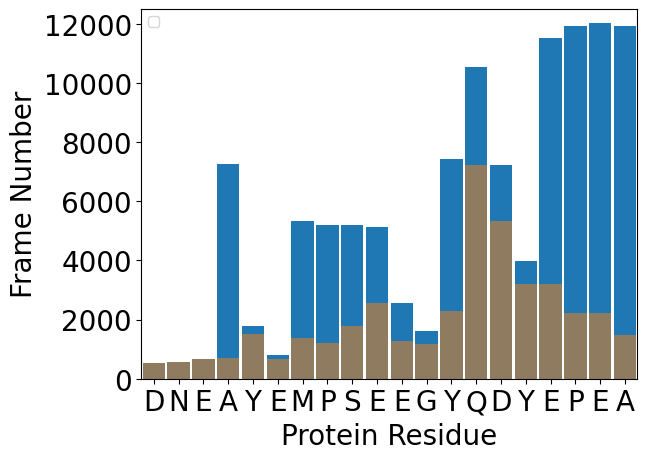

In [112]:
N = len(df)
M = len(df.columns)
indices = np.arange(N)
colors = ['steelblue', 'firebrick', 'darksage', 'goldenrod', 'gray'] * int(M / 5. + 1)
for i, label, color in zip(range(M), df.columns, colors):
    #kwargs = plot_kwargs
    #kwargs.update({'color': color, 'label': label})
    plt.bar(indices, df[label], width=0.9, alpha=.5 if i else 1)
    plt.xticks(indices + .5 * 0.9,
                   ['{}'.format(idx) for idx in df.index.values])
plt.legend()
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19],res_, fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(-0.5,19.5)
plt.ylim(0,12500)
#plt.title(title)
plt.xlabel('Protein Residue', fontsize=20)
plt.ylabel('Frame Number', fontsize=20)
plt.show()
